In [17]:
from pathlib import Path
import os
import tempfile

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="matplotlib-"))

import math
import re

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
import pandas as pd
import seaborn as sb


In [18]:
root = Path.cwd()
if not (root / "results" / "compilation.csv").exists():
    root = root.parent

data_path = root / "results" / "compilation.csv"
output_path = root / "results" / "compilation-real.svg"

time_pattern = re.compile(r"(?:(?P<minutes>\d+(?:\.\d+)?)m)?(?P<seconds>\d+(?:\.\d+)?)s")

def parse_duration(value: str) -> float:
    match = time_pattern.fullmatch(str(value).strip())
    if match is None:
        raise ValueError(f"Unsupported duration: {value!r}")
    return 60 * float(match.group("minutes") or 0) + float(match.group("seconds"))

def format_duration(seconds: float) -> str:
    minutes, remainder = divmod(seconds, 60)
    return f"{int(minutes)}:{remainder:04.1f}"


In [21]:
df = pd.read_csv(data_path)

for column in ["neon", "neofoam", "julia"]:
    df[column] = df[column].astype(str).str.lower().eq("true")

df = df[df["neon"] & ~df["neofoam"]].copy()
df["real_seconds"] = df["real"].map(parse_duration)
df["With(out) Julia"] = df["julia"].map({False: "Without Julia", True: "With Julia"})
df["Node"] = df["node"].str.upper()
df["Build"] = df["build"].str.upper()
df["Threads"] = df["threads"].astype(int).astype(str) + " threads"
df["x_group"] = df["Build"] + "\n" + df["Threads"]

build_order = ["GPU", "CPU"]
thread_order = ["32 threads", "64 threads"]
x_order = [f"{build}\n{threads}" for build in build_order for threads in thread_order]
hue_order = ["Without Julia", "With Julia"]


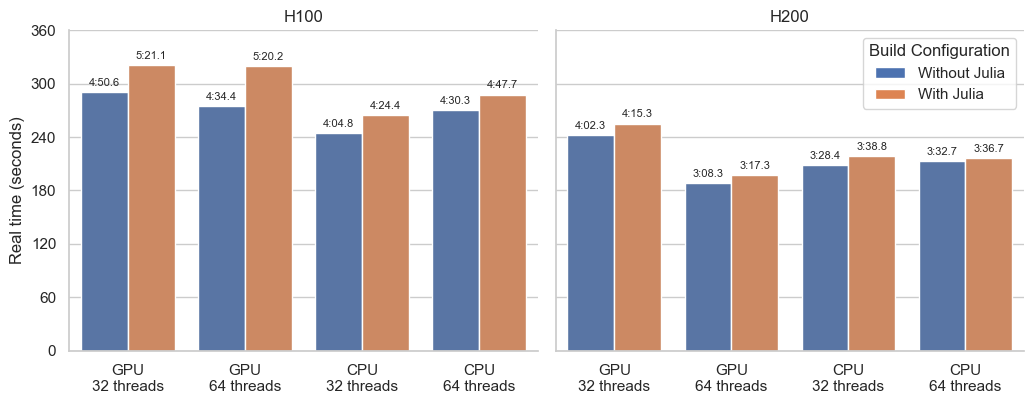

In [22]:
sb.set_theme(style="whitegrid")
palette = dict(zip(hue_order, sb.color_palette("deep", n_colors=2)))

g = sb.catplot(
    data=df,
    kind="bar",
    x="x_group",
    y="real_seconds",
    hue="With(out) Julia",
    col="Node",
    order=x_order,
    hue_order=hue_order,
    col_order=sorted(df["Node"].unique()),
    palette=palette,
    errorbar=None,
    height=4.2,
    aspect=1.25,
    legend=False,
)

g.set_titles("{col_name}")
g.set_axis_labels("", "Real time (seconds)")

for ax in g.axes.flat:
    ax.set_ylim(0, 360)
    ax.yaxis.set_major_locator(MultipleLocator(60))
    ax.grid(axis="x", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelrotation=0)
    for container in ax.containers:
        labels = [
            format_duration(bar.get_height()) if not math.isnan(bar.get_height()) else ""
            for bar in container
        ]
        ax.bar_label(container, labels=labels, padding=3, fontsize=8)

legend_handles = [Patch(facecolor=palette[label], label=label) for label in hue_order]
g.axes.flat[-1].legend(
    handles=legend_handles,
    title="Build Configuration",
    loc="upper right",
    frameon=True,
)

g.figure.tight_layout()
g.figure.savefig(output_path, bbox_inches="tight", metadata={"Date": None})
plt.show()
